**Decision_tree(titanic)**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv(r"C:\Users\LaptopWala\Downloads\archive (2)\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['Sex','Embarked']
for c in cols:
    df[c]=le.fit_transform(df[c])

In [20]:
df[['Sex','Embarked']].head()

,Sex,Embarked
0,1,2
1,0,0
2,0,2
3,0,2
4,1,2


In [21]:
df= df.drop(columns = ['Cabin','Name','Ticket','PassengerId'], axis = 1)


In [22]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [23]:
df['Age'].isnull().sum()

np.int64(177)

In [24]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = 'mean')
df[['Age']] = imputer.fit_transform(df[['Age']])
df['Age'].astype(int)

0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888    29
889    26
890    32
Name: Age, Length: 891, dtype: int64

In [25]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

4.787316519674893


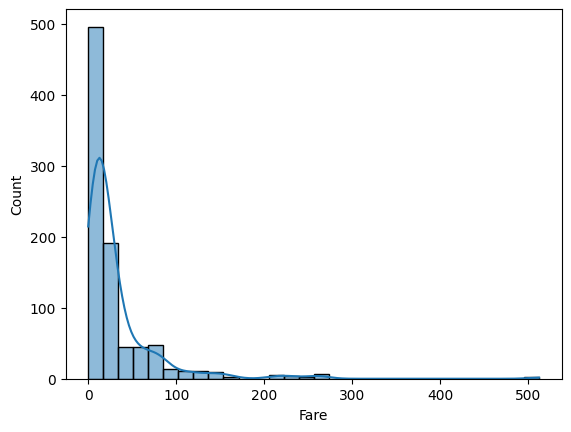

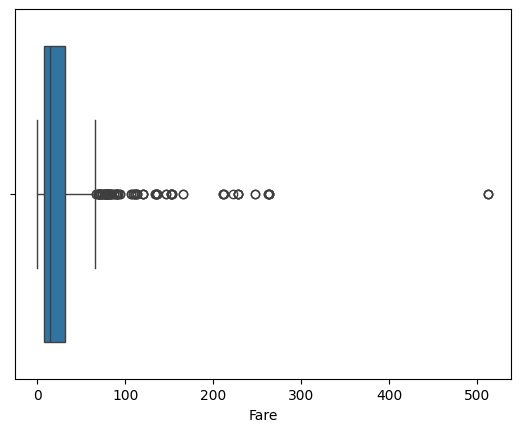

In [26]:
print(df['Fare'].skew())
sns.histplot(df["Fare"],bins = 30, kde = True)
plt.show()
sns.boxplot(x=df["Fare"])
plt.show()


In [27]:
df['Fare'] = np.log1p(df['Fare'])
print(df['Fare'].skew())

0.3949280095189306


In [28]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Fare"] = np.clip(df["Fare"], lower, upper)

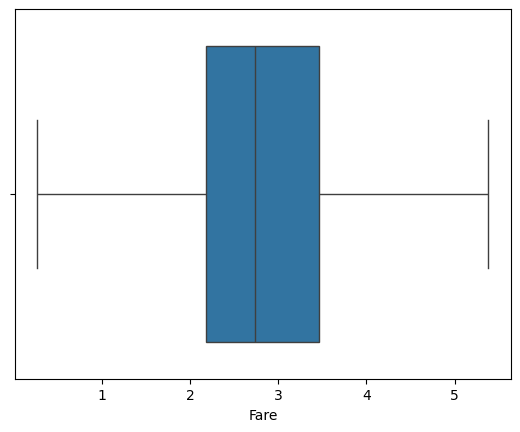

In [29]:
sns.boxplot(x=df['Fare'])
plt.show()

In [30]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.25, random_state=42)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [33]:
from sklearn.tree import DecisionTreeClassifier
model_default = DecisionTreeClassifier()
model_default.fit(X_train, y_train)
y_pred_default = model_default.predict(X_test)

In [34]:

from sklearn.metrics import accuracy_score, classification_report
print('Default Test Accuracy:', accuracy_score(y_test, y_pred_default))

Default Test Accuracy: 0.726457399103139


**Hyperparameter Tunning**

In [35]:
from sklearn.model_selection import GridSearchCV
parameter = {'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(),
    param_grid=parameter,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best hyperparameters:', grid_search.best_params_)
print('Accuracy:', grid_search.best_score_)

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
Best hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy: 0.8218493996184492


In [36]:
model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 7, max_features = 'sqrt', min_samples_leaf = 4, min_samples_split = 5)
model.fit(X_train, y_train)
y_pred_tuned = model.predict(X_test)
print('Test accuracy:', accuracy_score(y_test, y_pred_tuned))
print("classification_report:", classification_report(y_test, y_pred_tuned))

Test accuracy: 0.7982062780269058
classification_report:               precision    recall  f1-score   support

           0       0.82      0.85      0.84       134
           1       0.76      0.72      0.74        89

    accuracy                           0.80       223
   macro avg       0.79      0.78      0.79       223
weighted avg       0.80      0.80      0.80       223



In [37]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)
print(train_score)
print(test_score)

0.8607784431137725
0.7982062780269058
